# AAV9 — GT score study with the Potts-regression GT

Redoes `AAV9_fitting_protocol.ipynb`'s GT-score study (section 2b: deterministic GT score
distribution over the real library; sections 5-6: protocol-simulated log enrichment vs GT
score vs real target) with the GT source swapped: instead of the naive per-cell group-means
+ empirical-Bayes-shrunk `F_viab_GT`/`J_naive_final`, this notebook uses the joint
ridge-regularized Potts regression fit directly on `aav9.csv` in `AAV9_potts_regression.ipynb`
(`F_potts`/`J_potts`, loaded here via `lib/initialize_weights.load_F_viab_aav9_potts`/
`load_J_viab_aav9_potts`, not recomputed -- the ridge CV fit itself takes several minutes and
is already validated there).

Three things, as asked:
1. A few individual `J_potts[i, j]` position-pair couplings, shown directly (not surfaced
   anywhere else so far).
2. The distribution of the deterministic GT score (`compute_score(F_potts, J_potts)`, no
   protocol noise) across the real `aav9.csv` library.
3. The distribution of `target1` -- the log enrichment a *simulated* `Protocol` produces when
   seeded with this GT and run through one `loop_DE()` round, at the project's established
   baseline hyperparameters (`mu=50`, `T_viab=0.8`, `noise_viab=0.5`, `D=1e9`,
   `AAV9_fitting_protocol.ipynb` section 2) -- compared against both the GT score and the real
   `aav9.csv` target.

## 0. Setup

In [1]:
import sys, os

sys.path.insert(0, os.path.abspath("../lib"))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from analysisV1 import AA_LABELS, pearson
from sequence_classesV1 import ProtocolV3
from initialize_weights import (
    load_F_viab_aav9_potts, load_J_viab_aav9_potts, NUM_AMINO_ACIDS, NUM_POSITIONS,
)

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

message = "AAV9 Potts-GT score study 1.0"


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Real AAV9 data

In [2]:
df = pd.read_csv("aav9.csv")
print(f"{len(df):,} variants, columns: {list(df.columns)}")

lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
assert int(lengths[0]) == NUM_POSITIONS

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), NUM_POSITIONS)
target     = df["target"].to_numpy()

sequences = jnp.asarray(seq_matrix)
d0        = sequences.shape[0]

print(f"seq_matrix shape: {seq_matrix.shape}  (num_sequences, num_positions)")
print(f"d0 = {d0:,} real AAV9 library sequences")


68,776 variants, columns: ['sequence', 'target', 'error']
seq_matrix shape: (68776, 7)  (num_sequences, num_positions)
d0 = 68,776 real AAV9 library sequences


## 2. Potts-regression GT weights + baseline protocol config

`F_potts`/`J_potts` come from `AAV9_potts_regression.ipynb` (joint ridge regression fit
directly on this exact `aav9.csv`), loaded via `lib/initialize_weights.py`'s
`load_F_viab_aav9_potts`/`load_J_viab_aav9_potts` -- already in the right amino-acid/position
convention for `seq_matrix` above (same `build_J` convention as the naive GT).

`F_sel`/`J_sel` are zero, same reasoning as `AAV9_fitting_protocol.ipynb`: `loop_DE()`
computes `lambda0p`/`lambda2p` (-> `target1`, the viability log-enrichment) BEFORE
`selectivity()` runs, so `F_sel`/`J_sel` cannot influence anything plotted below.

Baseline config is the SAME project-established "best realistic" operating point used by
`AAV9_fitting_protocol.ipynb` (`mu_HEK_multiplicity_sweep.ipynb` / `T_viab_sweep.ipynb` /
`noise_viab_sweep.ipynb`): `mu=50`, `T_viab=0.8`, `noise_viab=0.5`, `D=1e9` -- kept identical
so the two GTs' resulting distributions are directly comparable, not confounded by a
different operating point.

In [3]:
F_potts = load_F_viab_aav9_potts()
J_potts = load_J_viab_aav9_potts()

F_sel = jnp.zeros_like(F_potts)
J_sel = jnp.zeros_like(J_potts)

RHO_REF          = 1e-3
MU_FIXED         = 50
T_VIAB_FIXED     = 0.8
NOISE_VIAB_FIXED = 0.5
D_FIXED          = 1e9
DILUTION_FACTOR  = 10
T_SEL_FIXED      = 1.0   # unused by target1, kept at the project default
eps              = 1.0

N1_FIXED = MU_FIXED * d0 / RHO_REF
N0_FIXED = N1_FIXED * 10

protocol = ProtocolV3(multinomialNGS=True, N0=N0_FIXED, N1=N1_FIXED,
        dilution_factor=DILUTION_FACTOR, sequences=sequences, D=D_FIXED,
        F_viab=F_potts, J_viab=J_potts, F_sel=F_sel, J_sel=J_sel,
        noise_viab=NOISE_VIAB_FIXED, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED,
        )

print(f"mu = {protocol._rho * protocol.N1 / d0:.2f}   N1={N1_FIXED:.3e}   N0={N0_FIXED:.3e}")


mu = 50.00   N1=3.439e+09   N0=3.439e+10


### 2a. A few `J_potts` instances

Position-pair coupling-strength heatmap (mean `|J_ij(a, b)|` over the 21 position pairs)
first, to pick out which pairs actually carry the strongest coupling, then the raw
(amino acid x amino acid) heatmap for a handful of those pairs -- what an individual `J[i, j]`
slice actually looks like, not just its aggregate magnitude.

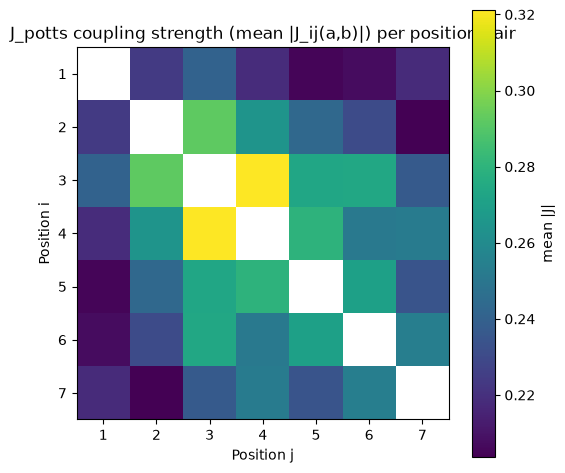

Strongest position pairs by mean |J|: [(3, 4), (2, 3), (4, 5), (3, 6)]


/tmp/ipykernel_1734181/1628788996.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


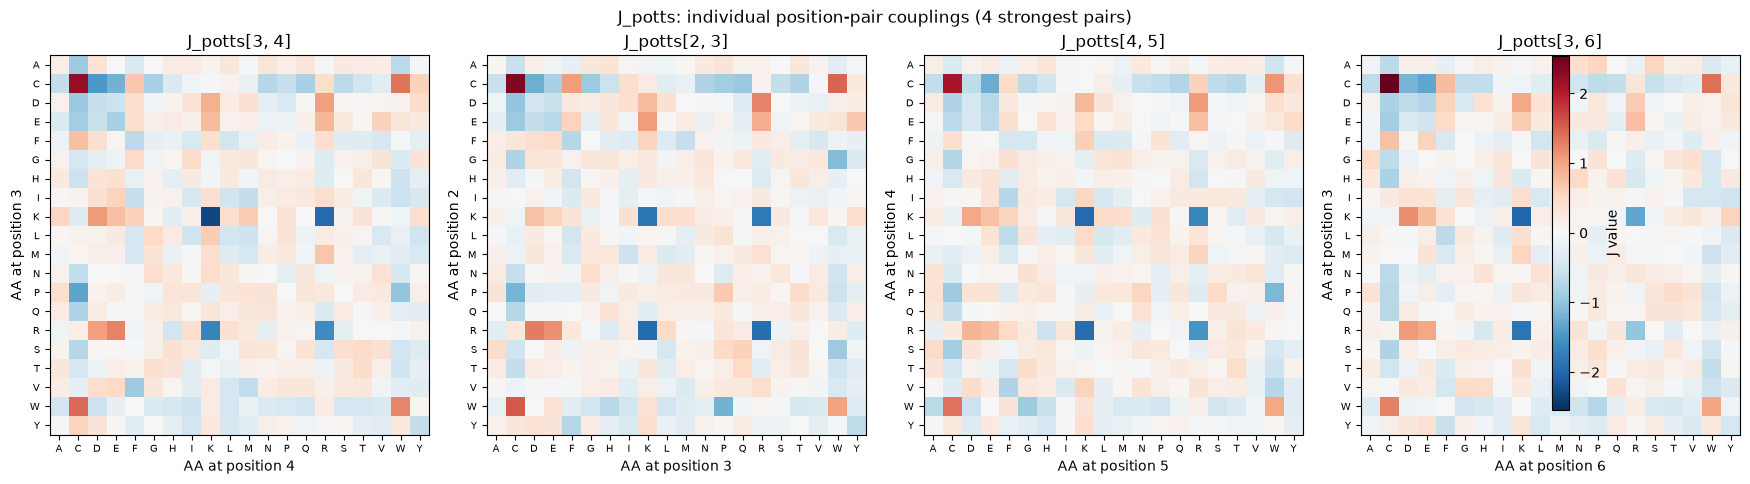

J_potts off-diagonal: mean|J|=0.2474  max|J|=4.1125


In [4]:
J_potts_np = np.array(J_potts)
off_diag_L = ~np.eye(NUM_POSITIONS, dtype=bool)


def coupling_strength(J):
    L = J.shape[0]
    off_diag = ~np.eye(L, dtype=bool)
    strength = np.full((L, L), np.nan)
    strength[off_diag] = np.nanmean(np.abs(J[off_diag]), axis=(1, 2))
    return strength


strength_potts = coupling_strength(J_potts_np)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(strength_potts, cmap="viridis")
ax.set_xlabel("Position j"); ax.set_ylabel("Position i")
ax.set_xticks(range(NUM_POSITIONS)); ax.set_xticklabels(range(1, NUM_POSITIONS + 1))
ax.set_yticks(range(NUM_POSITIONS)); ax.set_yticklabels(range(1, NUM_POSITIONS + 1))
ax.set_title("J_potts coupling strength (mean |J_ij(a,b)|) per position pair")
fig.colorbar(im, ax=ax, label="mean |J|")
fig.tight_layout()
plt.show()

pairs = [(i, j) for i in range(NUM_POSITIONS) for j in range(i + 1, NUM_POSITIONS)]
strongest_pairs = sorted(pairs, key=lambda p: -strength_potts[p])[:4]
print("Strongest position pairs by mean |J|:", [(i + 1, j + 1) for i, j in strongest_pairs])

vmax = max(np.abs(J_potts_np[i, j]).max() for i, j in strongest_pairs)
fig, axes = plt.subplots(1, len(strongest_pairs), figsize=(4.4 * len(strongest_pairs), 4.6))
for ax, (i, j) in zip(axes, strongest_pairs):
    im = ax.imshow(J_potts_np[i, j], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"J_potts[{i + 1}, {j + 1}]")
    ax.set_xticks(range(NUM_AMINO_ACIDS)); ax.set_xticklabels(AA_LABELS, fontsize=7)
    ax.set_yticks(range(NUM_AMINO_ACIDS)); ax.set_yticklabels(AA_LABELS, fontsize=7)
    ax.set_xlabel(f"AA at position {j + 1}"); ax.set_ylabel(f"AA at position {i + 1}")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.03, label="J value")
fig.suptitle("J_potts: individual position-pair couplings (4 strongest pairs)")
fig.tight_layout()
plt.show()

print(f"J_potts off-diagonal: mean|J|={np.mean(np.abs(J_potts_np[off_diag_L])):.4f}  "
      f"max|J|={np.max(np.abs(J_potts_np[off_diag_L])):.4f}")


### 2b. GT score distribution across the real AAV9 library

`viab_score_GT_potts = compute_score(F_potts, J_potts)` -- the deterministic F+J score for
every real sequence, no protocol simulation, no noise at all. Same construction as
`AAV9_fitting_protocol.ipynb` section 2b, with the naive GT swapped for the Potts-regression
one.

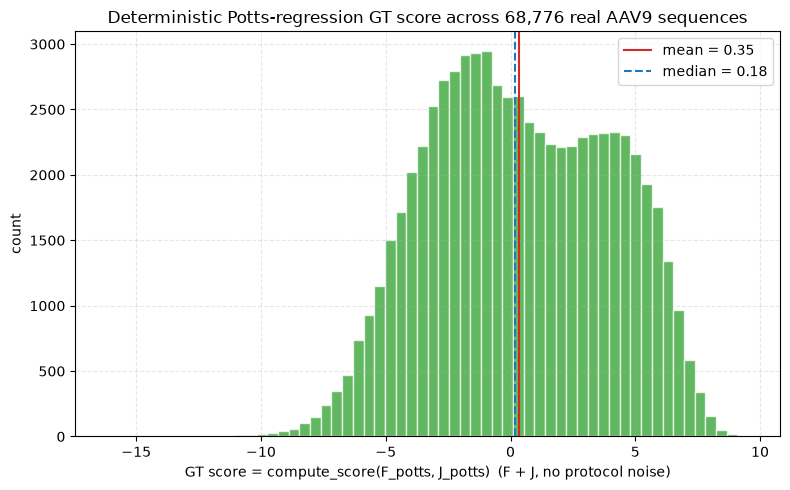

GT score (Potts): min=-16.16  max=9.52  mean=0.35  std=3.62
Pearson r(real aav9 target, GT-potts score) = +0.8888


In [5]:
viab_score_GT_potts = np.asarray(protocol.compute_score(F_potts, J_potts))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(viab_score_GT_potts, bins=60, color="tab:green", alpha=0.75, edgecolor="white")
ax.axvline(viab_score_GT_potts.mean(), color="tab:red", linestyle="-",
           label=f"mean = {viab_score_GT_potts.mean():.2f}")
ax.axvline(np.median(viab_score_GT_potts), color="tab:blue", linestyle="--",
           label=f"median = {np.median(viab_score_GT_potts):.2f}")
ax.set_xlabel("GT score = compute_score(F_potts, J_potts)  (F + J, no protocol noise)")
ax.set_ylabel("count")
ax.set_title(f"Deterministic Potts-regression GT score across {d0:,} real AAV9 sequences")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

r_gt_potts_vs_real = pearson(target, viab_score_GT_potts)
print(f"GT score (Potts): min={viab_score_GT_potts.min():.2f}  max={viab_score_GT_potts.max():.2f}  "
      f"mean={viab_score_GT_potts.mean():.2f}  std={viab_score_GT_potts.std():.2f}")
print(f"Pearson r(real aav9 target, GT-potts score) = {r_gt_potts_vs_real:+.4f}")


## 3. Protocol-simulated log enrichment using this GT

`viability_target1` runs one `loop_DE()` round on `protocol` (seeded with `F_potts`/`J_potts`
above) and returns `target1 = log((lambda2p + eps) / (lambda0p + eps))`, the viability
log-enrichment as estimated from simulated NGS reads only -- same construction as
`AAV9_fitting_protocol.ipynb`'s `viability_target1` (section 3 / 5).

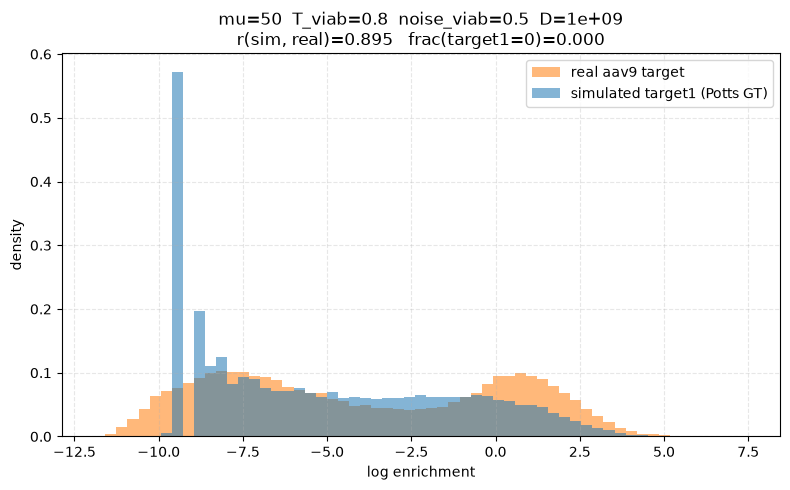

r(simulated target1, real target)     = +0.8951
r(simulated target1, GT-potts score)  = +0.9709
frac(target1 == 0)                    = 0.0000


In [6]:
def viability_target1(protocol, eps=eps):
    """Runs one loop_DE() round and returns target1 = log((lambda2p+eps)/(lambda0p+eps)).
    Resets lambda0 first, since loop_DE() depletes it in place."""
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    _bio_row, ngs_row = protocol.loop_DE()
    lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
    return np.log((lambda2p + eps) / (lambda0p + eps))


target1_potts = viability_target1(protocol)
r_sim_vs_real = pearson(target1_potts, target)
r_sim_vs_GT   = pearson(target1_potts, viab_score_GT_potts)
frac_zero     = float(np.mean(target1_potts == 0.0))

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(min(target.min(), target1_potts.min()),
                    max(target.max(), target1_potts.max()), 60)
ax.hist(target,        bins=bins, alpha=0.55, density=True, color="tab:orange", label="real aav9 target")
ax.hist(target1_potts, bins=bins, alpha=0.55, density=True, color="tab:blue",   label="simulated target1 (Potts GT)")
ax.set_xlabel("log enrichment")
ax.set_ylabel("density")
ax.set_title(f"mu={MU_FIXED:.3g}  T_viab={T_VIAB_FIXED:.3g}  noise_viab={NOISE_VIAB_FIXED:.3g}  D={D_FIXED:.3g}\n"
             f"r(sim, real)={r_sim_vs_real:.3f}   frac(target1=0)={frac_zero:.3f}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"r(simulated target1, real target)     = {r_sim_vs_real:+.4f}")
print(f"r(simulated target1, GT-potts score)  = {r_sim_vs_GT:+.4f}")
print(f"frac(target1 == 0)                    = {frac_zero:.4f}")


## 4. Overlay: GT score vs simulated log enrichment

`viab_score_GT_potts` (section 2b, deterministic F+J, no noise) vs `target1_potts` (section 3,
one stochastic `loop_DE()` run at the baseline hyperparameters) -- shows how much the
protocol's noise/`exp(score/T_viab)` transform reshapes the raw Potts-regression GT score into
the simulated log-enrichment distribution.

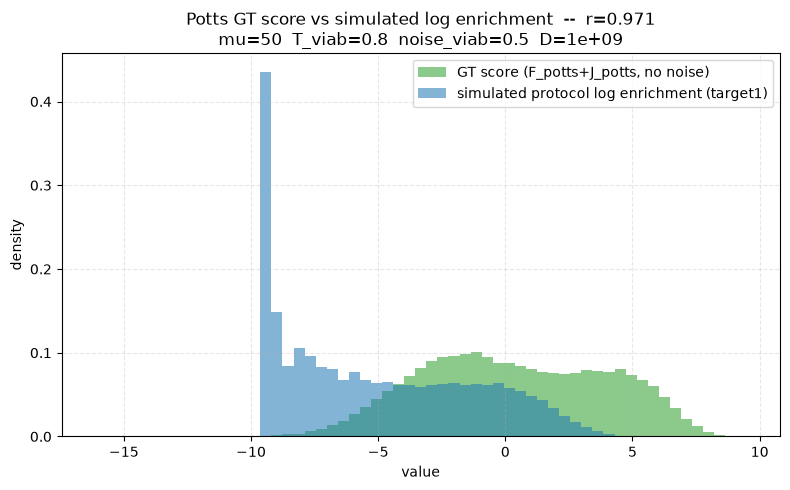

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
bins_score = np.linspace(min(viab_score_GT_potts.min(), target1_potts.min()),
                          max(viab_score_GT_potts.max(), target1_potts.max()), 60)
ax.hist(viab_score_GT_potts, bins=bins_score, alpha=0.55, density=True, color="tab:green",
        label="GT score (F_potts+J_potts, no noise)")
ax.hist(target1_potts, bins=bins_score, alpha=0.55, density=True, color="tab:blue",
        label="simulated protocol log enrichment (target1)")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.set_title(f"Potts GT score vs simulated log enrichment  --  r={r_sim_vs_GT:.3f}\n"
             f"mu={MU_FIXED:.3g}  T_viab={T_VIAB_FIXED:.3g}  noise_viab={NOISE_VIAB_FIXED:.3g}  D={D_FIXED:.3g}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()
